# MLALAD Fund Analytics — Amravati District, FY 2024-25

Run each cell with **Shift + Enter**. Charts and tables will display directly below each cell — no need to open separate PNG files.

## 1. Setup — import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# This line makes charts appear directly below each cell in Jupyter
%matplotlib inline

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#DDDDDD",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#EEEEEE",
})

ACCENT = "#3E6D9C"
ACCENT2 = "#C97B4A"

## 2. Load the dataset

In [2]:
df = pd.read_csv("mla_fund_dataset.csv")
df.head()

,Work_ID,MLA,Constituency,District,Financial_Year,Category,Work_Description,Village,Sanctioned_Amount,Spent_Amount,Remaining_Balance,Sanction_Date,Status
0,WRK0001,MLA - Amravati,Amravati,Amravati,2024-25,Roads,"Cement concrete road, Walgaon",Walgaon,1763000,1692600,70400,2024-12-24,Completed
1,WRK0002,MLA - Amravati,Amravati,Amravati,2024-25,Open Gym,"Outdoor fitness equipment, Chikhaldara",Chikhaldara,3928000,1186100,2741900,2024-10-05,Delayed
2,WRK0003,MLA - Amravati,Amravati,Amravati,2024-25,Water Tank / Drinking Water,"Overhead water tank construction, Rasulabad",Rasulabad,11662000,11058700,603300,2024-05-01,Completed
3,WRK0004,MLA - Amravati,Amravati,Amravati,2024-25,Drainage,"Nala (drain) improvement, Kurha",Kurha,2363000,2232200,130800,2024-11-11,Completed
4,WRK0005,MLA - Amravati,Amravati,Amravati,2024-25,Open Gym,"Outdoor fitness equipment, Kurha",Kurha,2125000,2028800,96200,2024-04-22,Completed


## 3. MLA-wise (constituency-wise) summary
Groups every work-level record by constituency and sums sanctioned/spent amounts.

In [3]:
mla_summary = (
    df.groupby(["MLA", "Constituency"])
    .agg(Sanctioned=("Sanctioned_Amount", "sum"),
         Spent=("Spent_Amount", "sum"),
         Works=("Work_ID", "count"))
    .reset_index()
)
mla_summary["Remaining"] = mla_summary["Sanctioned"] - mla_summary["Spent"]
mla_summary["Utilization_%"] = (mla_summary["Spent"] / mla_summary["Sanctioned"] * 100).round(1)
mla_summary = mla_summary.sort_values("Utilization_%", ascending=False)
mla_summary

,MLA,Constituency,Sanctioned,Spent,Works,Remaining,Utilization_%
0,MLA - Achalpur,Achalpur,35185000,32932100,14,2252900,93.6
2,MLA - Amravati (Additional Segment),Amravati (Additional Segment),38206000,33693800,10,4512200,88.2
4,MLA - Daryapur,Daryapur,43187000,35778900,10,7408100,82.8
8,MLA - Teosa,Teosa,39562000,30883500,13,8678500,78.1
1,MLA - Amravati,Amravati,43649000,33322400,14,10326600,76.3
3,MLA - Badnera,Badnera,45324000,31476800,11,13847200,69.4
5,MLA - Dhamangaon,Dhamangaon,30114000,20891800,12,9222200,69.4
7,MLA - Morshi,Morshi,31982000,22037300,10,9944700,68.9
6,MLA - Melghat,Melghat,34162000,18252600,12,15909400,53.4


### Chart: Utilization by Constituency

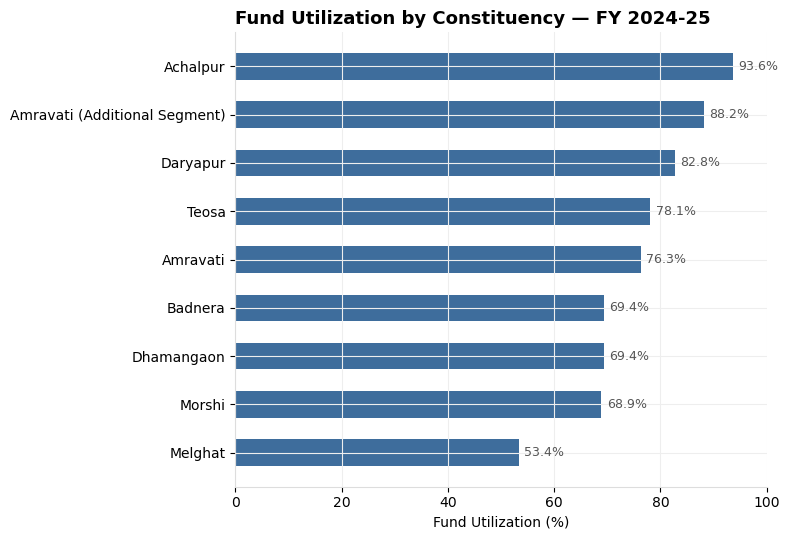

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
y = range(len(mla_summary))
ax.barh(y, mla_summary["Utilization_%"], color=ACCENT, height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(mla_summary["Constituency"])
ax.invert_yaxis()
ax.set_xlabel("Fund Utilization (%)")
ax.set_title("Fund Utilization by Constituency — FY 2024-25", loc="left", fontsize=13, weight="bold")
for i, v in enumerate(mla_summary["Utilization_%"]):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=9, color="#555555")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()  # <-- this displays the chart directly below the cell

## 4. Category-wise spend
Groups all work records by category (Roads, Water Tank, etc.)

In [5]:
category_summary = (
    df.groupby("Category")
    .agg(Sanctioned=("Sanctioned_Amount", "sum"), Spent=("Spent_Amount", "sum"))
    .reset_index()
    .sort_values("Spent", ascending=False)
)
category_summary

,Category,Sanctioned,Spent
5,Roads,80055000,64608900
4,Playground,51144000,43594900
8,Water Tank / Drinking Water,47114000,38919000
7,School Building & Equipment,40558000,23872300
2,Drainage,28654000,22963400
6,Sanitation,23957000,22199300
0,Community Hall,26002000,20102100
3,Open Gym,25918000,14096800
1,Compound Wall (Schools/Institutions),17969000,8912500


### Chart: Spend by Category

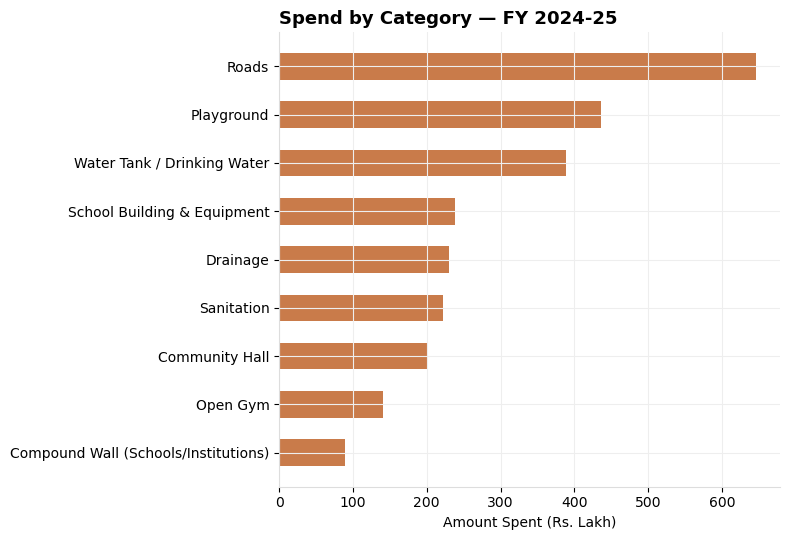

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cat_sorted = category_summary.sort_values("Spent")
ax.barh(cat_sorted["Category"], cat_sorted["Spent"] / 1e5, color=ACCENT2, height=0.55)
ax.set_xlabel("Amount Spent (Rs. Lakh)")
ax.set_title("Spend by Category — FY 2024-25", loc="left", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

## 5. Sanctioned vs Spent by constituency

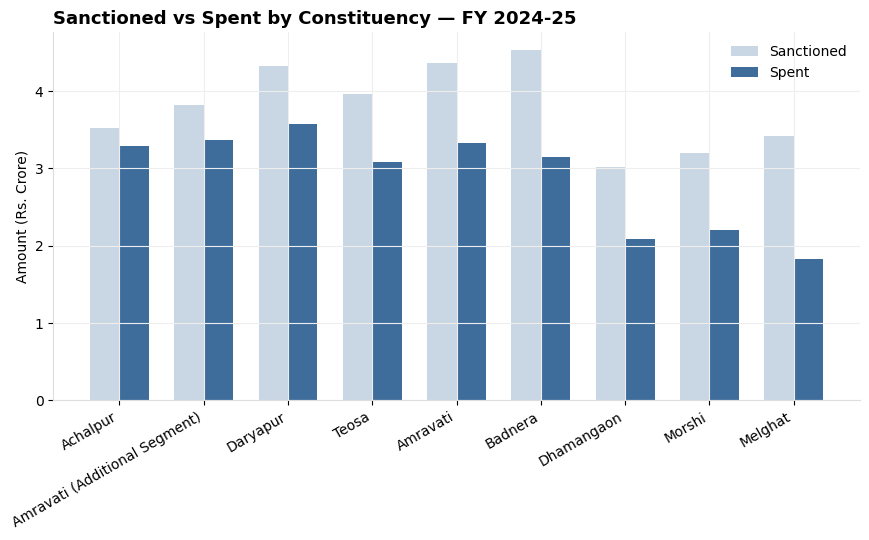

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = range(len(mla_summary))
w = 0.35
ax.bar([i - w/2 for i in x], mla_summary["Sanctioned"] / 1e7, width=w, label="Sanctioned", color="#C9D6E3")
ax.bar([i + w/2 for i in x], mla_summary["Spent"] / 1e7, width=w, label="Spent", color=ACCENT)
ax.set_xticks(x)
ax.set_xticklabels(mla_summary["Constituency"], rotation=30, ha="right")
ax.set_ylabel("Amount (Rs. Crore)")
ax.set_title("Sanctioned vs Spent by Constituency — FY 2024-25", loc="left", fontsize=13, weight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Work status distribution

In [8]:
status_summary = df["Status"].value_counts(normalize=True).mul(100).round(1).reset_index()
status_summary.columns = ["Status", "Percentage"]
status_summary

,Status,Percentage
0,Completed,62.3
1,In Progress,21.7
2,Delayed,10.4
3,Not Started,5.7


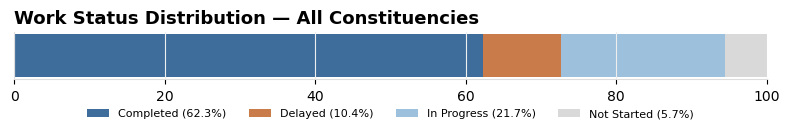

In [9]:
fig, ax = plt.subplots(figsize=(8, 1.8))
left = 0
status_colors = {"Completed": "#3E6D9C", "In Progress": "#9DC0DD",
                  "Delayed": "#C97B4A", "Not Started": "#D9D9D9"}
for _, row in status_summary.sort_values("Status").iterrows():
    ax.barh(0, row["Percentage"], left=left,
            color=status_colors.get(row["Status"], "#999999"),
            label=f"{row['Status']} ({row['Percentage']}%)", height=0.5)
    left += row["Percentage"]
ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_title("Work Status Distribution — All Constituencies", loc="left", fontsize=13, weight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.4), ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Headline insights (prints directly below)

In [10]:
total_sanctioned = df["Sanctioned_Amount"].sum()
total_spent = df["Spent_Amount"].sum()
util = round(total_spent / total_sanctioned * 100, 1)

print("===== HEADLINE INSIGHTS =====")
print(f"Total Sanctioned (9 MLAs, FY 2024-25): Rs {total_sanctioned:,}")
print(f"Total Spent: Rs {total_spent:,}")
print(f"Overall Utilization: {util}%")
print(f"Unspent / Remaining: Rs {total_sanctioned - total_spent:,}")
print(f"Top spending category: {category_summary.iloc[0]['Category']}")
print(f"Highest utilization: {mla_summary.iloc[0]['Constituency']} ({mla_summary.iloc[0]['Utilization_%']}%)")
print(f"Lowest utilization: {mla_summary.iloc[-1]['Constituency']} ({mla_summary.iloc[-1]['Utilization_%']}%)")

===== HEADLINE INSIGHTS =====
Total Sanctioned (9 MLAs, FY 2024-25): Rs 341,371,000
Total Spent: Rs 259,269,200
Overall Utilization: 75.9%
Unspent / Remaining: Rs 82,101,800
Top spending category: Roads
Highest utilization: Achalpur (93.6%)
Lowest utilization: Melghat (53.4%)


## 8. (Optional) Save outputs to files
Run this only if you also want the PNG/xlsx files saved to disk, in addition to seeing them above.

In [11]:
import os
os.makedirs("charts", exist_ok=True)

with pd.ExcelWriter("insights_summary.xlsx", engine="openpyxl") as writer:
    mla_summary.to_excel(writer, sheet_name="MLA_Summary", index=False)
    category_summary.to_excel(writer, sheet_name="Category_Summary", index=False)
    status_summary.to_excel(writer, sheet_name="Status_Summary", index=False)

print("Saved insights_summary.xlsx")

Saved insights_summary.xlsx
